### 1. 시계열 데이터 처리

In [ ]:
# AMZN.csv 읽으셔서 -> 날짜와 Close 변수만 남기세요
# -> Close 변수의 한 시점 전을 X변수로 만들어보세요.
#shift
import pandas as pd
df = pd.read_csv("AMZN.csv", parse_dates=[0])
df = df[["Date", "Close"]]
df["X1"] = df.Close.shift(1)
df["X2"] = df.Close.shift(2)
df["X3"] = df.X1.rolling(3).mean()
df["X4"] = df.X1.rolling(3).std()
df["X5"] = df.Date.dt.month
df.dropna(inplace=True)
#y변수에 대해서 X1~X5 regression
#LinearRegression, DecisionTreeRegressor
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
model1 = LinearRegression()
model2 = DecisionTreeRegressor()
model1.fit(df.drop(columns=["Close", "Date"]) , df.Close )
model2.fit(df.drop(columns=["Close", "Date"]) , df.Close )
#rolling
model1.score(df.drop(columns=["Close", "Date"]) , df.Close )

#diff
#df.Close.mean(), df.Close.std() #1866, 115
#df.Close[150:].mean(), df.Close[150:].std()
#df.Close.plot()
#df.Close.diff().plot() #stationary???
df.Close.pct_change()

#jena_climate....읽으셔서 -> "p (mbar)" 변수에 대해서 차분한 값, 원래값 평균, 편차 비교


- Sequential Dataset
 - Feature의 길이: Sequence Length ( = Window Size)
 - 예측할 길이: Step

- 예제 시계열 만들기

In [20]:
import numpy as np
import matplotlib.pyplot as plt

xarr = np.array([100,200,300,400])
yarr = np.array([1,2,3,4])
cond = ([True,False,True,False])
np.where(cond,xarr,yarr) #cond True->xarr, False ->yarr

array([100,   2, 300,   4])

In [21]:
np.random.seed(2020)
time = np.arange(30 * 12 + 1)
month_time = (time % 30) / 30

In [22]:
time_series = 20 * np.where(month_time < 0.5,
                          np.cos(2 * np.pi * month_time),
                          np.cos(2 * np.pi * month_time) + np.random.random(361))


In [23]:
time_series

array([ 2.00000000e+01,  1.95629520e+01,  1.82709092e+01,  1.61803399e+01,
        1.33826121e+01,  1.00000000e+01,  6.18033989e+00,  2.09056927e+00,
       -2.09056927e+00, -6.18033989e+00, -1.00000000e+01, -1.33826121e+01,
       -1.61803399e+01, -1.82709092e+01, -1.95629520e+01, -6.66393899e+00,
       -1.52209392e+01, -7.04236950e+00, -1.36967643e+01, -6.98788244e+00,
        9.06427746e+00, -3.43320407e+00,  9.29769267e+00,  2.16038789e+01,
        1.62476811e+01,  2.33532841e+01,  1.40664421e+01,  2.53027272e+01,
        2.13879364e+01,  2.90839313e+01,  2.00000000e+01,  1.95629520e+01,
        1.82709092e+01,  1.61803399e+01,  1.33826121e+01,  1.00000000e+01,
        6.18033989e+00,  2.09056927e+00, -2.09056927e+00, -6.18033989e+00,
       -1.00000000e+01, -1.33826121e+01, -1.61803399e+01, -1.82709092e+01,
       -1.95629520e+01, -1.68766917e+01, -6.82506738e+00, -7.15699540e+00,
       -1.23417656e+01, -4.86949247e+00,  2.68404157e-01, -7.92788173e-01,
        9.88983111e+00,  

In [4]:
time_series

import pandas as pd
ts = pd.DataFrame( time_series)

#75% train, 25% test,,,,,
ts[0:250]
ts[250:]

,0
250,-10.000000
251,-13.382612
252,-16.180340
253,-18.270909
254,-19.562952
...,...
356,32.976413
357,28.864236
358,34.389019
359,22.673496


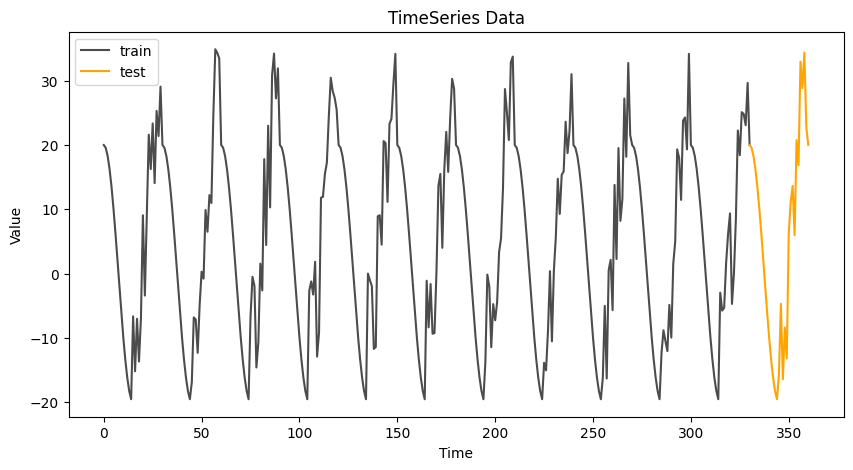

In [5]:
plt.figure(figsize = (10, 5))
plt.title('TimeSeries Data')
plt.xlabel('Time')
plt.ylabel('Value')
plt.plot(np.arange(0, 30 * 11 + 1), time_series[:30 * 11 + 1], color = 'black', alpha = 0.7, label = 'train') # 학습용 데이터
plt.plot(np.arange(30 * 11, 30 * 12 + 1), time_series[30 * 11:], color = 'orange', label = 'test') # 테스트용 데이터
plt.legend()

- 자료 읽어서 시계열

Date
2019-04-18   -0.001680
2019-04-22    0.013668
2019-04-23    0.019134
2019-04-24   -0.011512
2019-04-25    0.000263
                ...   
2020-04-09   -0.000117
2020-04-13    0.059905
2020-04-14    0.051424
2020-04-15    0.010612
2020-04-16    0.042633
Name: Close, Length: 251, dtype: float64

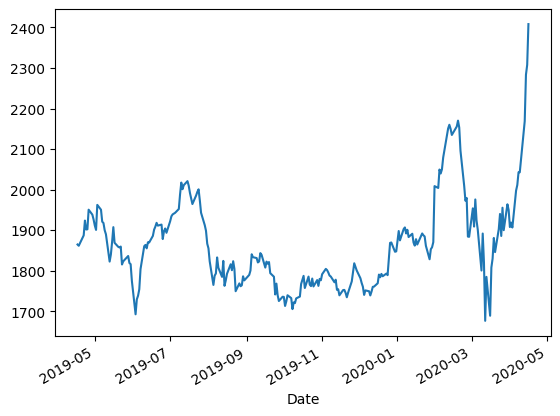

In [6]:
#AMZN.csv를 amazon으로 읽기
amazon = pd.read_csv( "AMZN.csv")
#amazon.Date컬럼을 pd.to_datetime 적용
amazon.index = pd.to_datetime(amazon["Date"])
#Date 컬럼을 지우기
amazon.drop("Date", axis=1, inplace=True)
amazon.Close.plot()
amazon.diff().dropna()  #differencing 차분
amazon.pct_change().dropna().Close  #수익율
np.log1p( amazon.pct_change().dropna().Close )  #로그수익율

In [7]:
# pykrx에서 00회사의 1년치 주가정보를 수집
!pip install pykrx

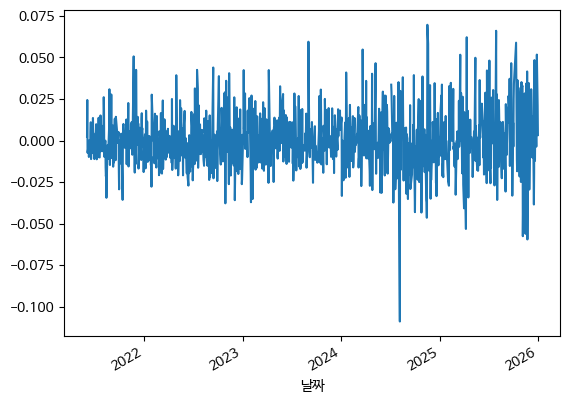

In [49]:
from pykrx import stock
df = stock.get_market_ohlcv_by_date("20210601", "20251231", "005930")

# 종가에 대해서 로그수익율, 수익율, 차분 구한 값들을 result라는 데이터프레임으로 묶어주세요
dif = df.diff().dropna().종가
ret = df.pct_change().dropna().종가
log_ret = np.log1p( df.pct_change().dropna().종가 )
result = pd.concat(   [dif, ret, log_ret     ], axis=1 )

# 로그수익율을 그리세요 ...
result.columns = ["차분", "수익율", "로그수익율"]
result.로그수익율.plot()

# 위의 데이터프레임을 csv로 만드세요  to_csv("파일명.csv")
result.to_csv("005930_2.csv")
df.to_csv("005930_3.csv")


    - https://s3.amazonaws.com/keras-datasets/jena_climate_2009_2016.csv.zip

In [ ]:
climate = pd.read_csv("jena_climate_2009_2016.csv")
climate["p (mbar)"].diff().mean()
climate["Date Time2"] =pd.to_datetime(
    climate["Date Time"],
    format="%d.%m.%Y %H:%M:%S"
)
climate.head()

In [59]:
climate.columns

Index(['Date Time', 'p (mbar)', 'T (degC)', 'Tpot (K)', 'Tdew (degC)',
       'rh (%)', 'VPmax (mbar)', 'VPact (mbar)', 'VPdef (mbar)', 'sh (g/kg)',
       'H2OC (mmol/mol)', 'rho (g/m**3)', 'wv (m/s)', 'max. wv (m/s)',
       'wd (deg)', 'Date Time2'],
      dtype='object')

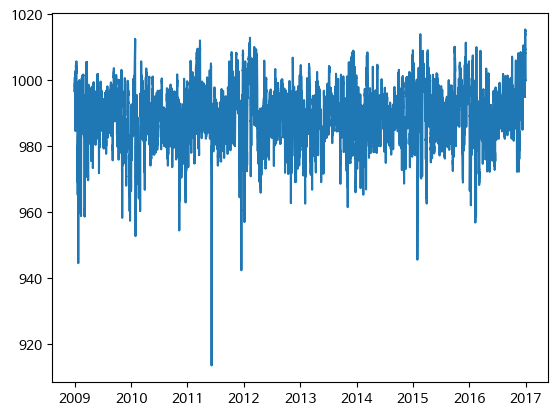

In [ ]:
from matplotlib import pyplot as plt
plt.plot(climate["Date Time2"], climate["p (mbar)"])
plt.show()

### 2. 시계열 데이터 처리

In [26]:
def make_sequence(time_series, n):  #시계열에서 1부터 n번째까지 선택해서 x로 지정, n+1번째값은 y, 이런 식으로 시계열 값을 계속 윈도우 n크기로 슬라이딩
    x_train, y_train = list(), list()

    for i in range(len(time_series)):
        x = time_series[i:(i + n)]
        if (i + n) < len(time_series):
            x_train.append(x)
            y_train.append(time_series[i + n])
        else:
            break

    return np.array(x_train), np.array(y_train)

n = 15
x_train, y_train = make_sequence(time_series, n)
#x_train = x_train.reshape(-1, n, 1)
#y_train = y_train.reshape(-1, 1)
#print(x_train.shape)
#print(y_train.shape)
x_train.shape
y_train.shape

(346,)

In [10]:
from sklearn.model_selection import train_test_split

partial_x_train = x_train[:30 * 11]
partial_y_train = y_train[:30 * 11]
x_test = x_train[30 * 11:]
y_test = y_train[30 * 11:]

print('train:', partial_x_train.shape, partial_y_train.shape)
print('test:',x_test.shape, y_test.shape)

train: (330, 15, 1) (330, 1)
test: (16, 15, 1) (16, 1)


In [11]:
test_arr = np.arange(100)
a, b = make_sequence(test_arr, 15)

for i in range(1, 4):
    print(a[i],'|', b[i])


[ 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15] | 16
[ 2  3  4  5  6  7  8  9 10 11 12 13 14 15 16] | 17
[ 3  4  5  6  7  8  9 10 11 12 13 14 15 16 17] | 18


In [ ]:
#AMZN.csv를 읽어서 Date를 index로 지정하세요.
df = pd.read_csv("AMZN.csv", parse_dates=[0], index_col=0)
df.resample("Y").mean()

### 3. 시계열 분석: ARIMA
 - 통계적 기법: ARIMA
 - 정상 프로세스 VS 비정상 프로세스
    - 정상 프로세스(Stationary Process): 시계열 자료의 평균과 분산이 시간에 관계없이 일정한 겨우 (trend나 seasonality가 없는)
    - 비정상 프로세스(Non-stationary Process): 시계열 자료의 평균과 분산이 일정하지 않은 경우

- 정상 VS 비정상 비교를 위해서 ACF를 확인
- Autocorrelation Function으로 특정 패턴이 없으면 정상 프로세스로 고려
    - ACF: 자기 상관 함수, k시간 단위로 구분된 시계열의 관측치 사이의 상관계수 함수, k가 커지면 ACF는 0에 가까워짐. 시차 k에 대한 두 관측치 상관계
 

- 정상성(Stationarity)
    - 시계열 자료가 정상성이 결여된 경우 모형의 성능이 좋지 않을 수 있음
    - 정상성이란: 시계열 자료가 뚜렷한 트렌드 없이 값의 변동이 시간의 흐름에 따라 일정, stationarity
        - 정상성 여부의 검정: Dickey Fuller의 단위근 검정
            - 귀무가설: 비정상시계열 (단위근 있다)
            - 대립가설: 정상시계열(단위근 없다)
         - 비정상시계열인 경우: 시계열 자료 차분(differencing)하여 정상시계열로 변환 후 피팅



- PACF(Partial ACF)
  - 부분상관(Partial Corr): 두 확률변수의 상관관계 중, 다른 변수들에 나타난 상관관계를 설명한 후에도, 여전히 남아있는 상관관계
  - PACF는 시계열 관측치 간의 상관관계, k시차에서의 '순수한' 상관관계(두 시점 사이 다른 관측치의 영향력은 제거)
  - t 시점의 y와 t-k 시점의 y의 편자기상관

- 모형
  - AR(Autoregressive) 모형: 자기 자신을 y로 하고, 시차 p인 이전 시점의 시계열 값들을 x변수로 하는 모형, 시차 p 를 하이퍼파라미터, 독립변수 간 독립성 가정 없음
  - MA 모형(Moving Average): 자기 자신이 y이고, 해당 시점과 시차 q인 과거의 white noise error들이 x변수인 모형, 하이퍼파라미터는 시차 q
  - ARMA모형(Autoregressive Moving Average): 자기 자신을 y로 하고, 이전 시점(p)의 시계열과 white noise error들을 x변수로 하는 모형, p,q가 하이퍼파라미터
  - ARIMA(Autoregressive Integrated Moving Average)모형: 위의 세 모형은 정상 프로세스에서의 경우, 비정상 프로세스는 차분을 통해 모형 적용, 차분을 d회 적용한 ARMA모형
    - 차분은 대체로 2회까지, 3회를 넘긴 경우 다른 모형 피팅

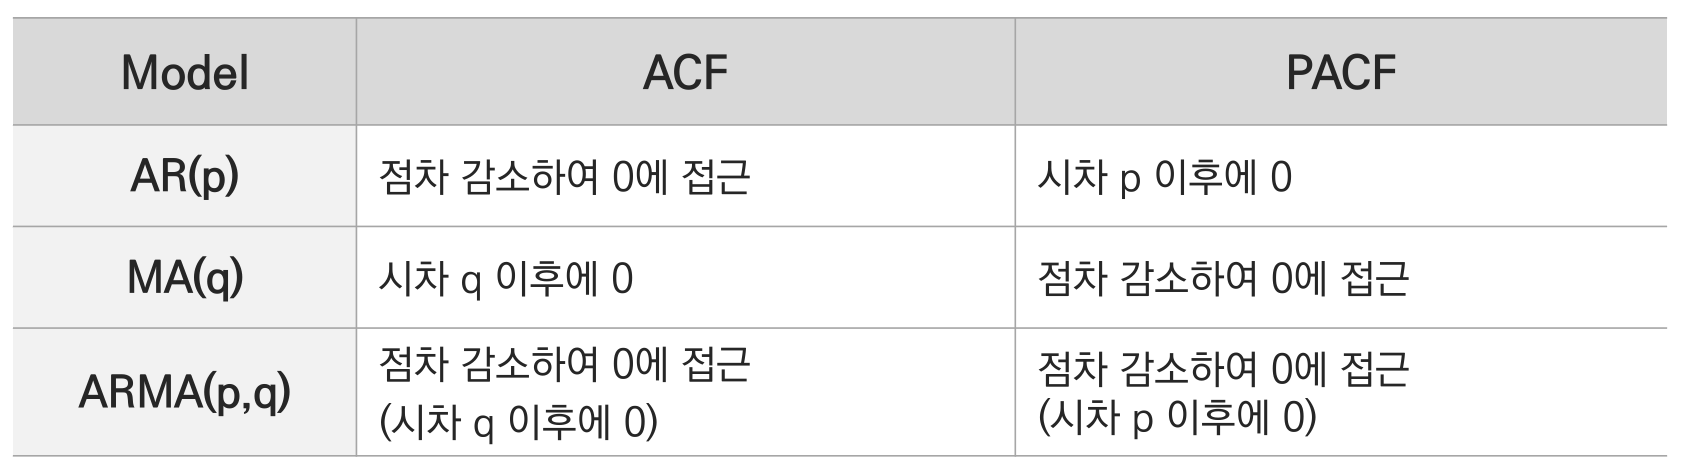

- ACF, PACF를 통해서 ARIMA 모형의 p,q를 결정, 자동으로 결정하게 시킴
  - AR(P)
    - ACF: 점차 감소 소멸하는 형태
    - PACF: p 시차 이후 0으로 절단
  - MA(q):
    - ACF: q 시차 이후 0으로 절단
    - PACF: 점차 감소 소멸하는 형태
  - ARMA(p,q)
    - ACF: 시차 q 이후 부터 소멸
    - PACF: 시차 p 이후부터 소멸
      - 예: p + q < 2, p * q = 0, 대부분은 한 경향을 갖기 때문
  - 모형 확인
    - Residuals에 대해서 ACF를 생성
    - 대부분이 영역 안에 들어오고, 40개 중 2-3개 까지는 영역 밖에 있어도 괜찮음

In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
dates = pd.date_range('2020-01-01', periods=48, freq='M')
timestamp = np.arange(len(dates))

trend_factor = timestamp*1.1
cycle_factor = 10*np.sin(np.linspace(0, 3.14*2, 48))
seasonal_factor = 7*np.sin(np.linspace(0, 3.14*8, 48))
np.random.seed(2004)
irregular_factor = 2*np.random.randn(len(dates))
df = pd.DataFrame(  {'timeseries': trend_factor + cycle_factor + seasonal_factor + irregular_factor,'trend': trend_factor,'cycle': cycle_factor,
                   'trend_cycle': trend_factor + cycle_factor,'seasonal': seasonal_factor,'irregular': irregular_factor},
                   index=dates)



C:\Users\user\AppData\Local\Temp\ipykernel_43024\3088315507.py:4: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  dates = pd.date_range('2020-01-01', periods=48, freq='M')


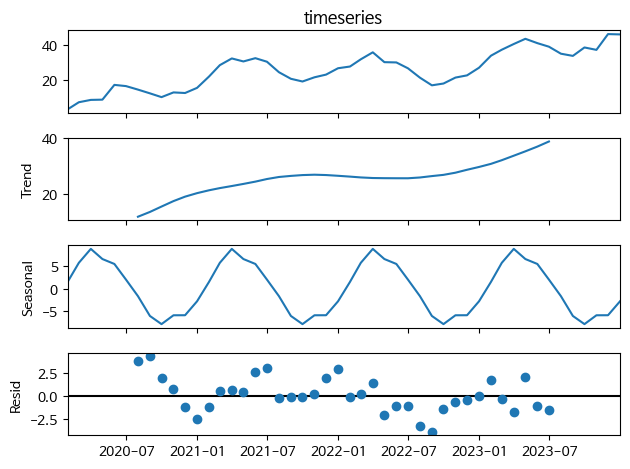

In [13]:
from statsmodels.tsa.seasonal import seasonal_decompose
result = seasonal_decompose(df.timeseries, model='additive')
result.plot()
plt.show()


- 판매 데이터에 대한 ARIMA

C:\Users\user\AppData\Local\Temp\ipykernel_43024\2705531099.py:6: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  series = read_csv('product.txt', header=0, parse_dates=[0], index_col=0)


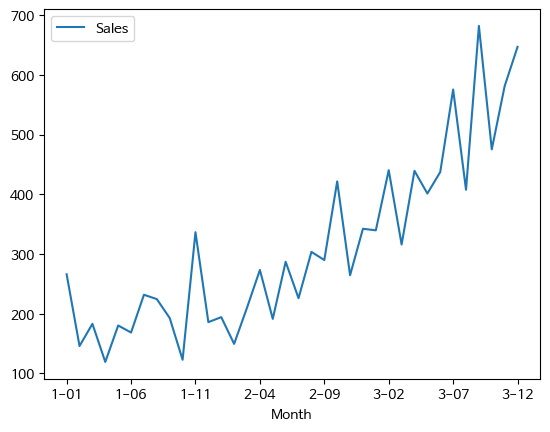

In [14]:
from pandas import read_csv
import datetime
from matplotlib import pyplot
from pandas.plotting import autocorrelation_plot

series = read_csv('product.txt', header=0, parse_dates=[0], index_col=0)
series.plot()
pyplot.show()


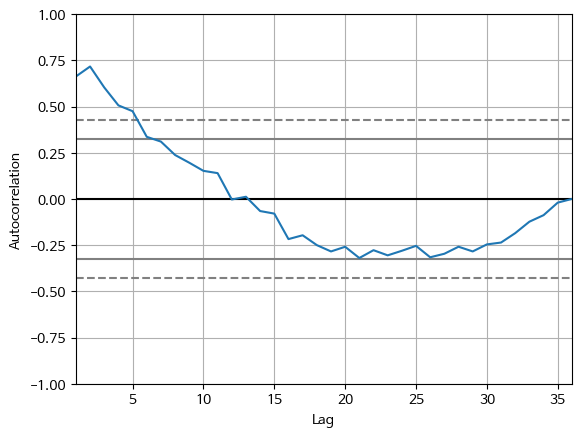

In [15]:
autocorrelation_plot(series)
pyplot.show()

In [16]:
month_return = series.pct_change().dropna()  #수익율
np.log( month_return.pct_change() + 1)  #로그수익율
(1+month_return).cumprod()-1  #누적수익율

c:\Users\user\miniconda3\envs\day3\Lib\site-packages\pandas\core\internals\blocks.py:395: RuntimeWarning: invalid value encountered in log
  result = func(self.values, **kwargs)


,Sales
Month,
1-02,-0.451504
1-03,-0.311654
1-04,-0.551504
1-05,-0.322180
1-06,-0.366541
1-07,-0.128571
1-08,-0.156015
1-09,-0.275188
1-10,-0.537970


c:\Users\user\miniconda3\envs\day3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:559: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  _index = to_datetime(index)
c:\Users\user\miniconda3\envs\day3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
c:\Users\user\miniconda3\envs\day3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:559: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  _index = to_datetime(index)
c:\Users\user\miniconda3\envs\day3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: Va

                               SARIMAX Results                                
Dep. Variable:                  Sales   No. Observations:                   36
Model:                 ARIMA(5, 1, 0)   Log Likelihood                -198.485
Date:                Wed, 22 Apr 2026   AIC                            408.969
Time:                        18:52:24   BIC                            418.301
Sample:                             0   HQIC                           412.191
                                 - 36                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.9014      0.247     -3.647      0.000      -1.386      -0.417
ar.L2         -0.2284      0.268     -0.851      0.395      -0.754       0.298
ar.L3          0.0747      0.291      0.256      0.7

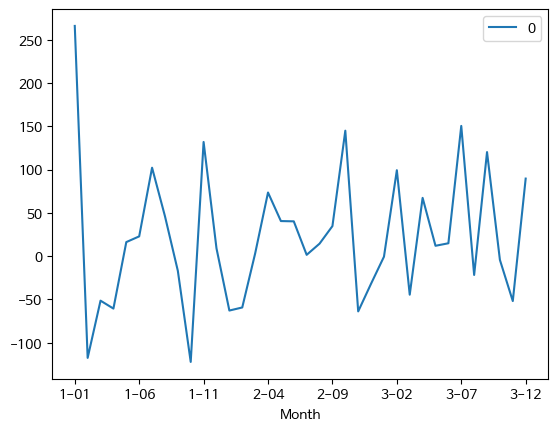

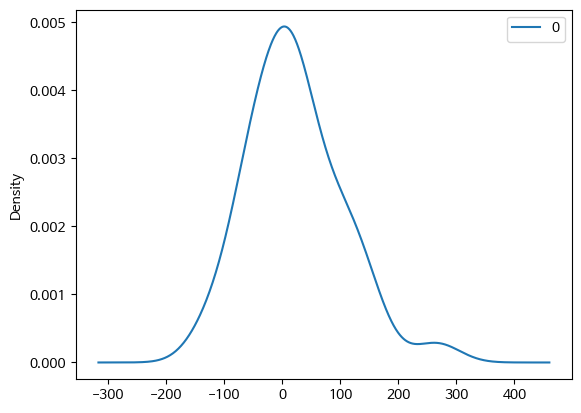

                0
count   36.000000
mean    21.936144
std     80.774430
min   -122.292030
25%    -35.040859
50%     13.147219
75%     68.848286
max    266.000000


In [17]:
from statsmodels.tsa.arima.model import ARIMA
# fit model
model = ARIMA(series, order=(5,1,0))
model_fit = model.fit()
# summary of fit model
print(model_fit.summary())
# line plot of residuals
residuals = pd.DataFrame(model_fit.resid)
residuals.plot()
pyplot.show()
# density plot of residuals
residuals.plot(kind='kde')
pyplot.show()
# summary stats of residuals
print(residuals.describe())

### 4. partitioning후 예측

In [18]:
from sklearn.metrics import mean_squared_error
from math import sqrt

# split into train and test sets
X = series.values
size = int(len(X) * 0.66)
train, test = X[0:size], X[size:len(X)]
history = [x for x in train]
predictions = list()


In [19]:
model = ARIMA(history, order=(5,1,0))
model_fit = model.fit()
output = model_fit.forecast(len(test))
print(output)

for t in range(len(test)):
  yhat = output[t]
  predictions.append(yhat)
  obs = test[t]
  history.append(obs[0])
  print('predicted=%f, expected=%f' % (yhat, obs[0]))


[343.27218056 293.64819178 363.68618293 306.69336249 331.89063437
 312.92063342 336.30040446 320.99834298 326.85663021 321.13512607
 327.74557234 324.36459909 325.45644431]
predicted=343.272181, expected=342.300000
predicted=293.648192, expected=339.700000
predicted=363.686183, expected=440.400000
predicted=306.693362, expected=315.900000
predicted=331.890634, expected=439.300000
predicted=312.920633, expected=401.300000
predicted=336.300404, expected=437.400000
predicted=320.998343, expected=575.500000
predicted=326.856630, expected=407.600000
predicted=321.135126, expected=682.000000
predicted=327.745572, expected=475.300000
predicted=324.364599, expected=581.300000
predicted=325.456444, expected=646.900000


Test RMSE: 181.932


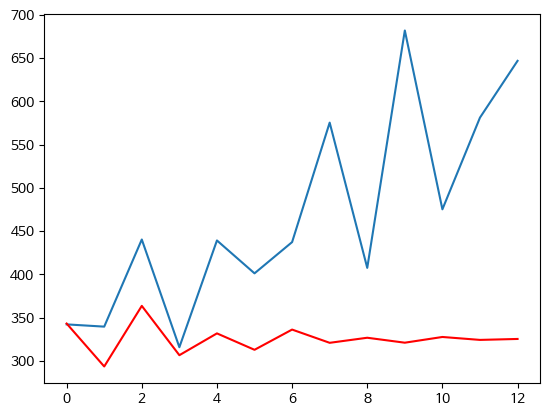

In [20]:
# evaluate forecasts
rmse = sqrt(mean_squared_error(test, predictions))
print('Test RMSE: %.3f' % rmse)

# plot forecasts against actual outcomes
pyplot.plot(test)
pyplot.plot(predictions, color='red')
pyplot.show()

- 주가 시계열 데이터에 대한 예

In [21]:
import pandas as pd
data=pd.read_csv('AMZN.csv', header=0,index_col="Date")
data.info()
data.describe()

<class 'pandas.core.frame.DataFrame'>
Index: 252 entries, 2019-04-17 to 2020-04-16
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Open       252 non-null    float64
 1   High       252 non-null    float64
 2   Low        252 non-null    float64
 3   Close      252 non-null    float64
 4   Adj Close  252 non-null    float64
 5   Volume     252 non-null    int64  
dtypes: float64(5), int64(1)
memory usage: 13.8+ KB


,Open,High,Low,Close,Adj Close,Volume
count,252.000000,252.000000,252.000000,252.000000,252.000000,2.520000e+02
mean,1864.800556,1883.242064,1846.651429,1866.393093,1866.393093,4.060800e+06
std,110.513502,116.543016,110.148293,114.338644,114.338644,2.035731e+06
min,1641.510010,1725.000000,1626.030029,1676.609985,1676.609985,8.813000e+05
25%,1778.007507,1793.577515,1762.510040,1783.422516,1783.422516,2.748850e+06
50%,1842.005005,1870.639954,1826.875000,1854.284973,1854.284973,3.410900e+06
75%,1921.224945,1936.729981,1898.567535,1912.812469,1912.812469,4.754375e+06
max,2346.000000,2461.000000,2335.000000,2408.189941,2408.189941,1.556730e+07


In [22]:
print(data.head())

                   Open         High          Low        Close    Adj Close  \
Date                                                                          
2019-04-17  1872.989990  1876.469971  1860.439941  1864.819946  1864.819946   
2019-04-18  1868.790039  1870.819946  1859.479980  1861.689941  1861.689941   
2019-04-22  1855.400024  1888.420044  1845.640015  1887.310059  1887.310059   
2019-04-23  1891.199951  1929.260010  1889.579956  1923.770020  1923.770020   
2019-04-24  1925.000000  1929.689941  1898.160034  1901.750000  1901.750000   

             Volume  
Date                 
2019-04-17  2893500  
2019-04-18  2749900  
2019-04-22  3373800  
2019-04-23  4640400  
2019-04-24  3675800  


In [23]:
data.shape

(252, 6)

In [24]:
from statsmodels.tsa.stattools import adfuller    #종가의 정상성 여부 점검
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
import pandas as pd  #데이터프레임.diff()

In [25]:
#AMZN.csv를 읽으셔서->Adj.Close값에 대해서 ARIMA 피팅
data0 = pd.read_csv("AMZN.csv")
data0.shape

(252, 7)

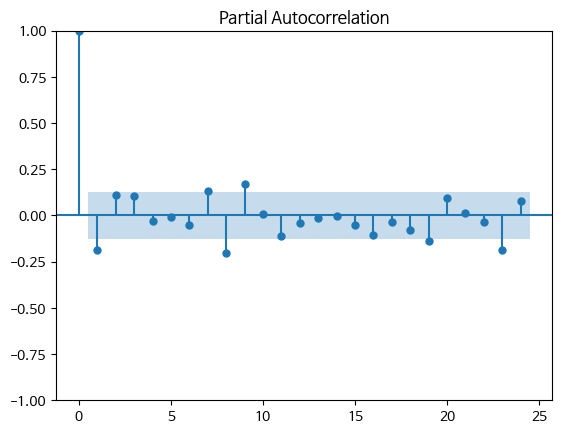

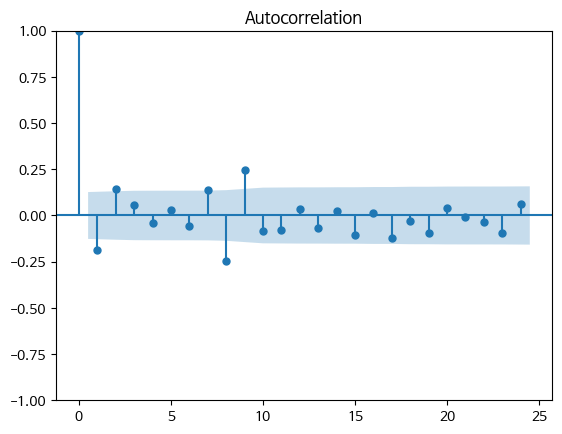

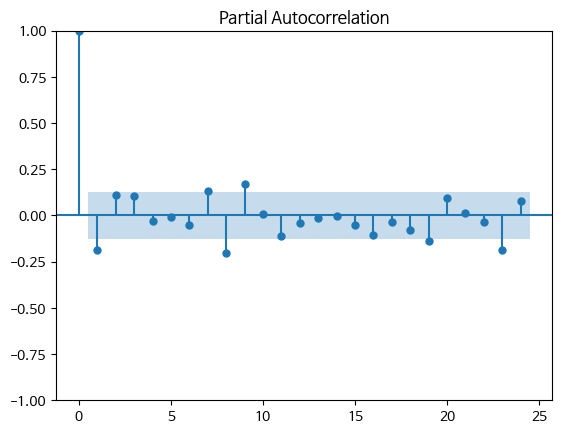

In [26]:
data = data0.iloc[0:240,:]
test = data0.iloc[240:, :]
data.columns
adfuller(data["Adj Close"].diff().dropna()) #d:1
series = data["Adj Close"].diff().dropna()
plot_acf(series)  #q: 2
plot_pacf( series ) #p: 2

In [27]:
#p,d,q = (1,1,1)
model1 = ARIMA( data["Adj Close"], order=(3,1,1)).fit()
print(model1.summary())
#SARIMAX, LSTM, GRU....

                               SARIMAX Results                                
Dep. Variable:              Adj Close   No. Observations:                  240
Model:                 ARIMA(3, 1, 1)   Log Likelihood               -1170.083
Date:                Wed, 22 Apr 2026   AIC                           2350.166
Time:                        18:52:25   BIC                           2367.548
Sample:                             0   HQIC                          2357.171
                                - 240                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.9876      0.103     -9.629      0.000      -1.189      -0.787
ar.L2         -0.0077      0.070     -0.110      0.912      -0.145       0.130
ar.L3          0.1943      0.055      3.557      0.0

In [28]:
np.mean( (model1.forecast(12) - test["Adj Close"])**2 )**0.5 #RMSE

np.float64(205.18138272047185)

### 5. 정상성 검정: Dicky-Fuller Test

In [29]:
#!pip install statsmodels
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller    #종가의 정상성 여부 점검
result=adfuller(data['Close'])
print(result) #0.5933이 p-value, 비정상 시계열

(np.float64(-2.9217621203516506), np.float64(0.042875254602457974), 9, 230, {'1%': np.float64(-3.459105583381277), '5%': np.float64(-2.8741898504150574), '10%': np.float64(-2.5735117958412097)}, np.float64(2189.3010749622676))


- acf, pacf
 - acf: 자기상관함수, autocorrelation function, k기간 떨어진 값들의 상관 계수
 - pacf: 편자기상관함수, partial autocorrelation function, 서로 다른 두 지점 사이의 관계를 분석할때, 중간에 있는 값들의 영향을 제외시킨 상관계수

 - p가 증가 시, 지수적 감소 혹은 절단 형태여야 정상성, 둘 중 하나라도 느리게 감소하거나 증가 시 비정상성

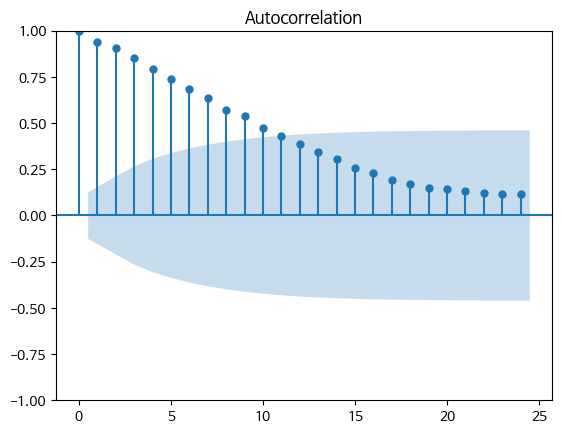

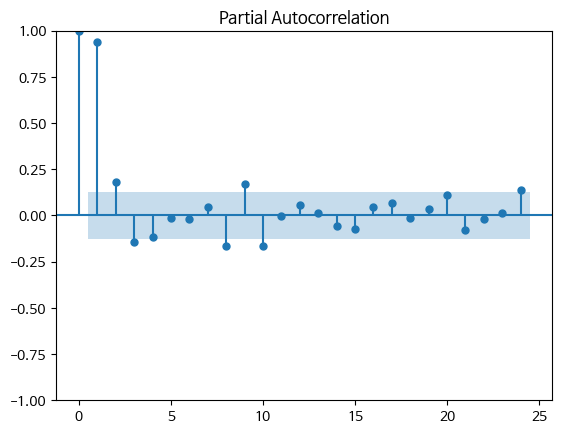

In [30]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
plot_acf(data['Close']) #느리게 감소, 비정상시계열
plot_pacf(data['Close'])
plt.show()

In [31]:
data["Close"].diff() #differencing 차이를 구해줌 ->주가가 아닌 경우에 사용

0            NaN
1      -3.130005
2      25.620118
3      36.459961
4     -22.020020
         ...    
235    37.270020
236   -54.260010
237    69.650024
238   -55.390014
239    63.849975
Name: Close, Length: 240, dtype: float64

count    239.000000
mean       0.000217
std        0.018283
min       -0.082535
25%       -0.008060
50%        0.000263
75%        0.008613
max        0.071196
Name: Close, dtype: float64


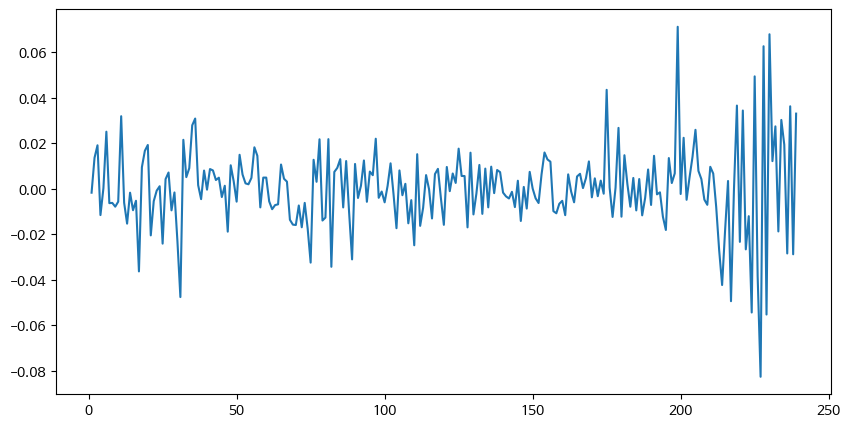

In [32]:
import numpy as np
datapct=data.Close.pct_change()   #주가인 경우 수익율
logreturn=np.log(1+datapct) #로그수익율
logreturn.head()
print(logreturn.describe())
plt.figure(figsize=(10,5))
plt.plot(logreturn)
plt.show()

In [33]:
logreturn.dropna()  #NAN을 제거

1     -0.001680
2      0.013668
3      0.019134
4     -0.011512
5      0.000263
         ...   
235    0.019397
236   -0.028366
237    0.036267
238   -0.028734
239    0.033051
Name: Close, Length: 239, dtype: float64

In [34]:
from statsmodels.tsa.stattools import adfuller
logreturn=logreturn.dropna()
result=adfuller(logreturn) #p-value < 0.05
print(result)

(np.float64(-4.487566075585139), np.float64(0.000207066656520397), 8, 230, {'1%': np.float64(-3.459105583381277), '5%': np.float64(-2.8741898504150574), '10%': np.float64(-2.5735117958412097)}, np.float64(-1168.0386740968868))


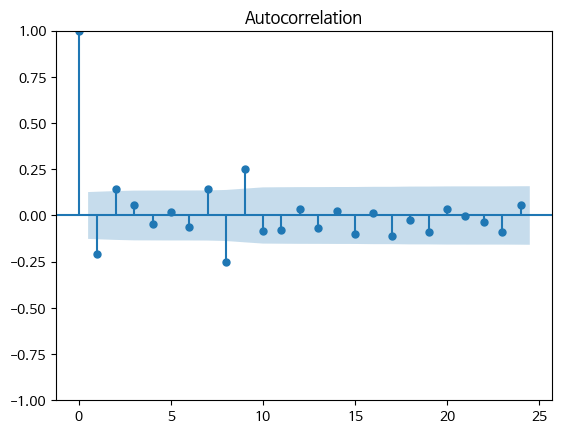

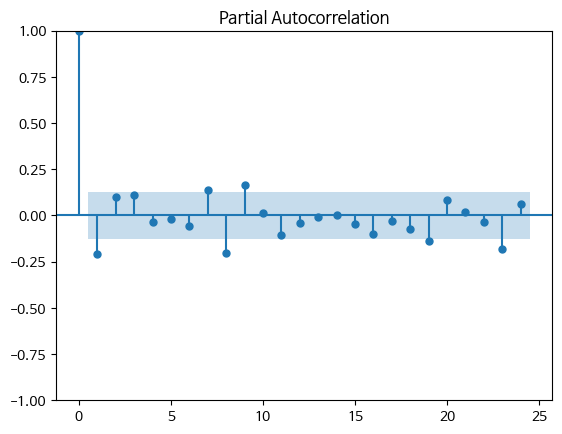

<class 'pandas.core.series.Series'>


In [35]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
plot_acf(logreturn)
plot_pacf(logreturn) #그림에서 절단이 일어나는 위치를 p의 값으로 지정, 24?
plt.show()
print(type(logreturn))

### 6. 모형 검정

In [36]:
from statsmodels.tsa.arima.model import ARIMA
model = ARIMA(data['Close'], order=(0,2,1))
model_fit = model.fit()
print(model_fit.summary())

                               SARIMAX Results                                
Dep. Variable:                  Close   No. Observations:                  240
Model:                 ARIMA(0, 2, 1)   Log Likelihood               -1178.159
Date:                Wed, 22 Apr 2026   AIC                           2360.318
Time:                        18:52:26   BIC                           2367.263
Sample:                             0   HQIC                          2363.117
                                - 240                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ma.L1         -0.9988      0.128     -7.825      0.000      -1.249      -0.749
sigma2      1142.5503    150.681      7.583      0.000     847.222    1437.879
Ljung-Box (L1) (Q):                   8.53   Jarque-

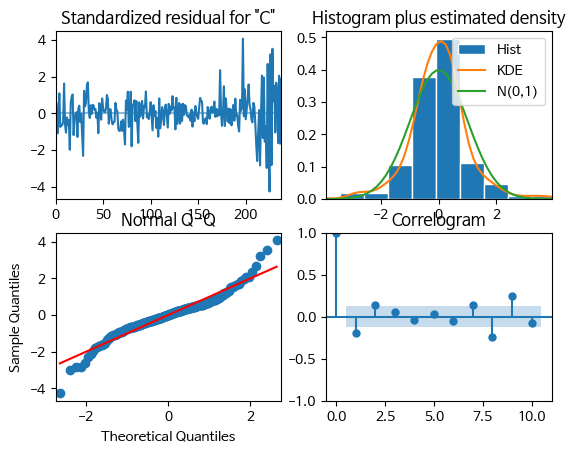

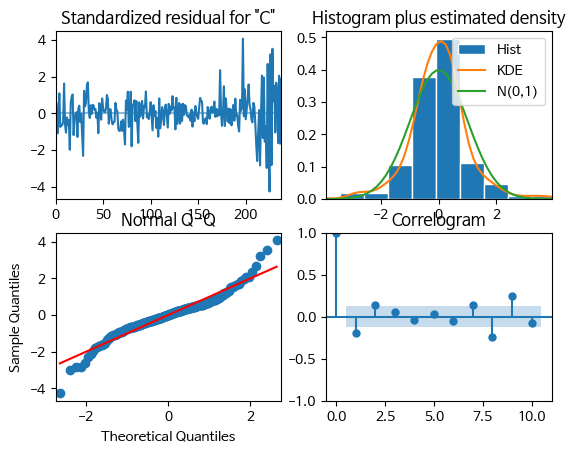

In [37]:
model_fit.plot_diagnostics()

In [38]:
forecasted = model_fit.forecast(steps=1)
print(forecasted)

240    1964.386067
dtype: float64


- 다양한 p,d,q 확인

In [39]:
import itertools

p = range(0,3)
d = range(1,2)
q = range(0,6)

pdq = list(itertools.product(p,d,q))

aic = []
params = []

for i in pdq:
        try:
            model = ARIMA(data["Close"], order=(i))
            model_fit = model.fit()
            aic.append(round(model_fit.aic,2))
            params.append((i))
        except:
            continue

c:\Users\user\miniconda3\envs\day3\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
c:\Users\user\miniconda3\envs\day3\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
c:\Users\user\miniconda3\envs\day3\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
c:\Users\user\miniconda3\envs\day3\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameter

In [40]:
optimal = [(params[i],j) for i,j in enumerate(aic) if j == min(aic)]
model_opt = ARIMA(data["Close"], order = optimal[0][0])
model_opt_fit = model_opt.fit()
model_opt_fit.summary()

c:\Users\user\miniconda3\envs\day3\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
c:\Users\user\miniconda3\envs\day3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                  Close   No. Observations:                  240
Model:                 ARIMA(2, 1, 5)   Log Likelihood               -1165.764
Date:                Wed, 22 Apr 2026   AIC                           2347.528
Time:                        18:52:31   BIC                           2375.340
Sample:                             0   HQIC                          2358.735
                                - 240                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -1.6203      0.047    -34.592      0.000      -1.712      -1.529
ar.L2         -0.8854      0.047    -18.804      0.000      -0.978      -0.793
ma.L1          1.5449      0.069     22.435      0.000       1.410       1.680
ma.L2          0.8605      0.095      9.088      0.000       0.675       1.046
ma.L3          0.1767      0.112      1.577      0.115      -0.043       0.396
ma.L4          0.3268      0.100      3.263      0.001       0.131       0.523
ma.L5          0.2275      0.051      4.440      0.000       0.127       0.328
sigma2       947.2929     55.298     17.131      0.000     838.910    1055.675
===================================================================================
Ljung-Box (L1) (Q):                   0.28   Jarque-Bera (JB):                90.25
Prob(Q):                              0.60   Prob(JB):                         0.00
Heteroskedasticity (H):               2.38   Skew:                             0.23
Prob(H) (two-sided):                  0.00   Kurtosis:                         5.98
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [41]:
model = ARIMA(data["Close"], order=optimal[0][0])
model_fit = model.fit()
forecast = model_fit.forecast(steps=24*7)

c:\Users\user\miniconda3\envs\day3\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
c:\Users\user\miniconda3\envs\day3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


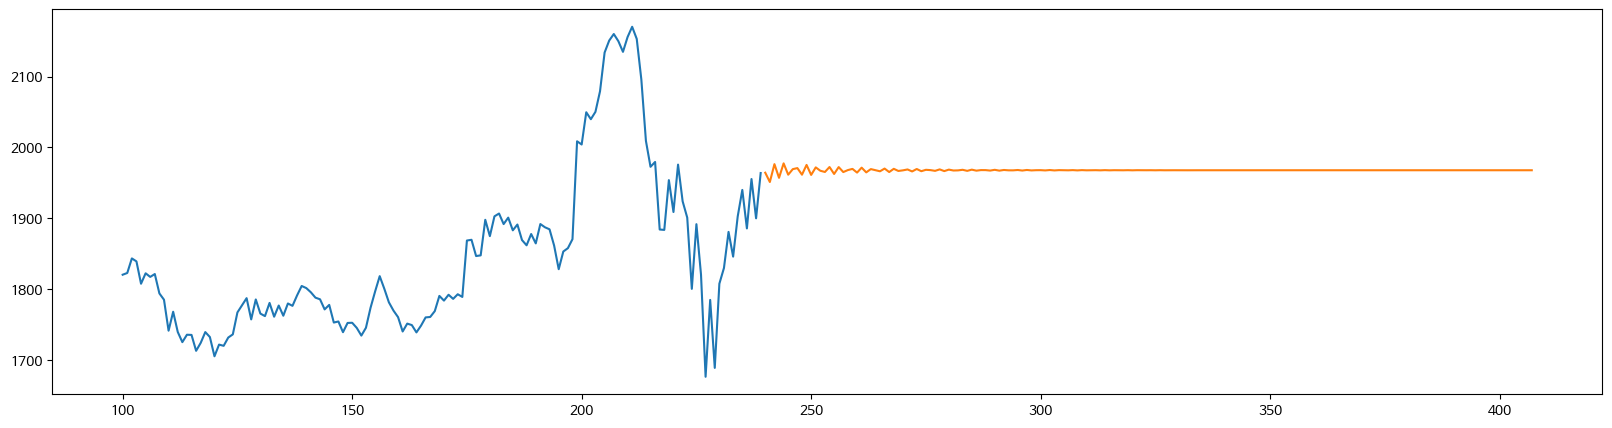

In [42]:
plt.figure(figsize=(20,5))
plt.plot(range(100,240), data["Close"].iloc[100:])
plt.plot(forecast)

### 7. Autoarima: 자동으로 p,d, q 확인

In [ ]:
!pip install pmdarima

In [90]:
df.columns

Index(['Date Time', 'p (mbar)', 'T (degC)', 'Tpot (K)', 'Tdew (degC)',
       'rh (%)', 'VPmax (mbar)', 'VPact (mbar)', 'VPdef (mbar)', 'sh (g/kg)',
       'H2OC (mmol/mol)', 'rho (g/m**3)', 'wv (m/s)', 'max. wv (m/s)',
       'wd (deg)'],
      dtype='object')

In [ ]:
# import necessary libraries
# jena_climate 자료를-> 일별 평균 df.resample('D').mean()
# -> p (mbar)에 대해서 ARIMA
# model.summary()
import pmdarima as pm
import pandas as pd
import numpy as np
df = pd.read_csv("jena_climate_2009_2016.csv")
df["Date Time"] =pd.to_datetime(
    df["Date Time"],
    format="%d.%m.%Y %H:%M:%S"
)
df.index = df["Date Time"]
#월별 기온에 대해서 auto_arima, 예측
df2 = df.resample('M').mean()  #df2["p (mbar)"].plot()
from statsmodels.tsa.stattools import adfuller  #H0:비정상, H1:정상
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
data_actual = df2["T (degC)"].dropna()
data_actual.plot()
adfuller(data_actual ) 
plot_acf(data_actual)   
plot_pacf(data_actual)
model = pm.auto_arima(data_actual, seasonal=True, m=12, d=1)#연간주기
model.summary()
model.predict(1)
model.plot_diagnostics()  

In [ ]:
#005930_3.csv를 읽어서 종가에 대해 시계열 모형을 만드세요.
#최근 10개는 test로 빼놓으시고, 나머지로 모델링하세요.
#auto_arima, ML regression, linear regression으로 
#10개의 test에 대해서 RMSE 비교해보세요   

In [128]:
df = pd.read_csv("005930_3.csv")
df1 = df[["날짜","종가"]]
df1.columns = ["date", "close"]
#df1.close.plot()
train = df1[:1114]
test = df1[1114:]

In [ ]:
#1. arima
adfuller(train.close.diff().dropna())  #d=1
#plot_acf(train.close.diff().dropna())   #q=0
#plot_pacf(train.close.diff().dropna())  #p=0
model1 = pm.auto_arima(train.close, d=1, m=8, seasonal=True, trace=True,
                        start_p=1, start_q=1, )

In [ ]:
model1.summary()
#model.plot_diagnostics()
pred1 = model1.predict(10)
root_mean_squared_error( pred1, test.close)

8565.687362961597

In [ ]:
df1["X1"] = df1.close.shift(1)
df1["X2"] = df1.close.shift(2)
df1["X3"] = df1.X1.rolling(3).mean()
df1["X4"] = df1.X1.rolling(3).std()
tmp = pd.get_dummies(pd.to_datetime(df1.date).dt.day_of_week)
df1 = pd.concat( [ df1, tmp], axis=1).dropna()

In [130]:
df1.columns

Index(['date', 'close', 'X1', 'X2', 'X3', 'X4', 0, 1, 2, 3, 4], dtype='object')

In [ ]:
df1.columns = ["date", "close", "x1","x2","x3","x4","x5","x6","x7","x8","x9"]
df1.drop(columns="date", inplace=True)

In [149]:
train = df1[:1114]
train2 = df1[900:1114]
test = df1[1114:]

#2. ML
from sklearn.ensemble import RandomForestRegressor
model2 = RandomForestRegressor()
model2.fit( train.drop(columns="close"), train.close)
pred2 = model2.predict( test.drop(columns="close"))
root_mean_squared_error(pred2, test.close)

8735.032766313554

In [ ]:
#3. Linear
model3 = LinearRegression()
model3.fit( train2.drop(columns="close"), train2.close)
pred3 = model3.predict( test.drop(columns="close"))
print( root_mean_squared_error(pred3, test.close) )

from sklearn.metrics import mean_absolute_percentage_error
mean_absolute_percentage_error(pred3, test.close) 

2814.8391700531006


0.019118524406717192

In [ ]:
#005930_3.csv -> 종가(처음~75%) arima ->p,d,q를 확인
#75%~끝 ->예측값과 비교 -> rmse
data_actual = pd.read_csv("005930_3.csv")["종가"]
train = data_actual[:800] 
test  = data_actual[800:] 
test.shape
train.diff().plot()

In [66]:
model = pm.auto_arima( train)
model.summary()
from sklearn.metrics import root_mean_squared_error
root_mean_squared_error(model.predict(20), test[0:20])

9346.443173742618

In [ ]:
# import necessary libraries
import pmdarima as pm
import pandas as pd
import numpy as np

data_actual = pd.read_csv("AMZN.csv")["Close"]

# set seasonal to True
seasonal = True

# use pmdarima to automatically select best ARIMA model
model = pm.auto_arima(data_actual,
                      m=12,               # frequency of series
                      seasonal=seasonal,  # TRUE if seasonal series
                      d=0,             # let model determine 'd'
                      test='adf',         # use adftest to find optimal 'd'
                      start_p=0, start_q=0, # minimum p and q
                      max_p=12, max_q=12, # maximum p and q
                      D=None,             # let model determine 'D'
                      trace=True,
                      error_action='ignore',
                      suppress_warnings=True,
                      stepwise=True)

# print model summary
print(model.summary())

### 8. Time series로 X, y 생성 후 머신러닝 회귀

In [45]:
def make_sequence(time_series, n):  #시계열에서 1부터 n번째까지 선택해서 x로 지정, n+1번째값은 y, 이런 식으로 시계열 값을 계속 윈도우 n크기로 슬라이딩
    x_train, y_train = list(), list()

    for i in range(len(time_series)):
        x = time_series[i:(i + n)]
        if (i + n) < len(time_series):
            x_train.append(x)
            y_train.append(time_series[i + n])
        else:
            break

    return np.array(x_train), np.array(y_train)


In [46]:
# amazon.com의 close 컬럼을 사용하여 sequence를 만들기 (make_sequence, time step=....
data = pd.read_csv("AMZN.csv")
x_train, y_train = make_sequence( data.Close.values, 3)
x_train = x_train.reshape( -1, 3, 1)
y_train = y_train.reshape( -1, 1)

# 1.5 처음부터225개까지가 train, 226~252까지 test
x_train2 = x_train[ : 225]
y_train2 = y_train[ : 225]
x_test = x_train[ 225: ]
y_test = y_train[ 225: ]

In [47]:
datapct=data.Close.pct_change()   #주가인 경우 수익율
logreturn=np.log(1+datapct) #로그수익율
logreturn.head()
print(logreturn.describe())


count    251.000000
mean       0.001019
std        0.019030
min       -0.082535
25%       -0.007880
50%        0.000514
75%        0.008992
max        0.071196
Name: Close, dtype: float64


In [48]:
#로그 수익율에 대해 적용
logr1=logreturn.values
logr=logr1.reshape(1,-1)
inte=13 #pacf의 p값
x=[]
y=[]
for i in range(logr.shape[1]):
    if i+inte>logr.shape[1]-1:
        break
    else:
         xx=logr[0,i:i+inte]
         x.append(xx)
         yy=logr[0,i+inte]
         y.append(yy)
x=np.array(x)
y=np.array(y)
x_train=x[:100]
x_test=x[100:]
y_train=y[:100]
y_test=y[100:]